<a href="https://colab.research.google.com/github/MohammedMujtabaAnsari/MACHINE-LEARNING-/blob/main/CNN_PRACTICAL_PROJECT_CAT_AND_DOG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout,Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os
import matplotlib.image as mpimg

In [ ]:
 #Importing Dataset
from zipfile import ZipFile
data_path = 'archive.zip'
with ZipFile(data_path, 'r') as zip:
  zip.extractall()
  print('The data set has been extracted.')

The data set has been extracted.


In [ ]:
fig = plt.gcf()
fig.set_size_inches(16, 16)

<Figure size 1600x1600 with 0 Axes>

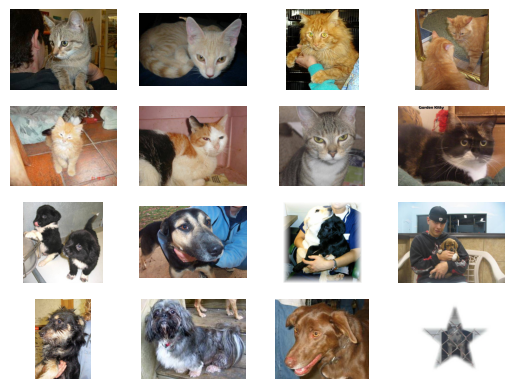

In [ ]:
cat_dir = os.path.join('/content/cats_set')
dog_dir = os.path.join('/content/dogs_set')
cat_names = os.listdir(cat_dir)
dog_names = os.listdir(dog_dir)
pic_index = 210
cat_images = [os.path.join(cat_dir, fname)
  for fname in cat_names[pic_index-8:pic_index]]
dog_images = [os.path.join(dog_dir, fname)
  for fname in dog_names[pic_index-8:pic_index]]
for i, img_path in enumerate(cat_images + dog_images):
  sp = plt.subplot(4, 4, i+1)
  sp.axis('Off')
  img = mpimg.imread(img_path)
  plt.imshow(img)
plt.show()

In [ ]:
import shutil

base_dir = '/content/train_transformed'

# Source directories for original images
source_cat_dir = '/content/cats_set'
source_dog_dir = '/content/dogs_set'

# Create target subdirectories within base_dir
target_cat_subdir = os.path.join(base_dir, 'cat')
target_dog_subdir = os.path.join(base_dir, 'dog')
os.makedirs(target_cat_subdir, exist_ok=True)
os.makedirs(target_dog_subdir, exist_ok=True)

# Move images from source to target subdirectories
# This assumes 'cats_set' and 'dogs_set' have been extracted (e.g., by cell MBaJ_b-yPH2G)
if os.path.exists(source_cat_dir):
    for filename in os.listdir(source_cat_dir):
        if filename.startswith('cat'): # Ensure only cat images are moved
            shutil.move(os.path.join(source_cat_dir, filename), os.path.join(target_cat_subdir, filename))
if os.path.exists(source_dog_dir):
    for filename in os.listdir(source_dog_dir):
        if filename.startswith('dog'): # Ensure only dog images are moved
            shutil.move(os.path.join(source_dog_dir, filename), os.path.join(target_dog_subdir, filename))

print('Images have been organized into cat and dog subdirectories in', base_dir)

# Now proceed with dataset creation
train_datagen = image_dataset_from_directory(base_dir,labels = 'inferred',label_mode = 'binary',image_size=(200,200),subset='training',seed = 1,validation_split=0.1,batch_size=32)
test_datagen = image_dataset_from_directory(base_dir,labels = 'inferred',label_mode = 'binary',image_size=(200,200),subset='validation',seed = 1,validation_split=0.1,batch_size=32)

Images have been organized into cat and dog subdirectories in /content/train_transformed
Found 1000 files belonging to 2 classes.
Using 900 files for training.
Found 1000 files belonging to 2 classes.
Using 100 files for validation.


In [ ]:
import shutil

base_dir = '/content/train_transformed'

# Create subdirectories for 'cat' and 'dog'
cat_subdir = os.path.join(base_dir, 'cat')
dog_subdir = os.path.join(base_dir, 'dog')
os.makedirs(cat_subdir, exist_ok=True)
os.makedirs(dog_subdir, exist_ok=True)

# Move images to respective subdirectories
for filename in os.listdir(base_dir):
    if filename.startswith('cat'):
        shutil.move(os.path.join(base_dir, filename), os.path.join(cat_subdir, filename))
    elif filename.startswith('dog'):
        shutil.move(os.path.join(base_dir, filename), os.path.join(dog_subdir, filename))

print('Images have been organized into cat and dog subdirectories.')

Error: Cannot move a directory '/content/train_transformed/cat' into itself '/content/train_transformed/cat/cat'.

In [ ]:
base_dir = '/content/train_transformed'
train_datagen = image_dataset_from_directory(base_dir,image_size=(200,200),subset='training',seed = 1,validation_split=0.1,batch_size=32)
test_datagen = image_dataset_from_directory(base_dir,image_size=(200,200),subset='validation',seed = 1,validation_split=0.1,batch_size=32)

Found 1000 files belonging to 2 classes.
Using 900 files for training.
Found 1000 files belonging to 2 classes.
Using 100 files for validation.


In [ ]:
os.listdir('/content')

['.config',
 'cats_set',
 'archive.zip',
 'train_transformed',
 'drive',
 'dogs_set',
 'sample_data']

In [ ]:
model = tf.keras.models.Sequential([
layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(200, 200, 3)),
layers.MaxPooling2D(2, 2),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D(2, 2),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D(2, 2),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D(2, 2),
layers.Flatten(),
layers.Dense(512, activation='relu'),
layers.BatchNormalization(),
layers.Dense(512, activation='relu'),
layers.Dropout(0.1),
layers.BatchNormalization(),
layers.Dense(512, activation='relu'),
layers.Dropout(0.2),
layers.BatchNormalization(),
layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,902,529 (14.89 MB)

 Trainable params: 3,899,457 (14.88 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [ ]:
model.compile(
loss='binary_crossentropy',
optimizer='adam',
metrics=['accuracy']
)
history = model.fit(train_datagen,
epochs=10,
validation_data=test_datagen)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.5145 - loss: 1.0180 - val_accuracy: 0.4800 - val_loss: 2.3042
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.5581 - loss: 0.8426 - val_accuracy: 0.4800 - val_loss: 3.5650
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.5806 - loss: 0.8218 - val_accuracy: 0.5300 - val_loss: 1.8347
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6420 - loss: 0.6665 - val_accuracy: 0.5000 - val_loss: 0.9816
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.6346 - loss: 0.6445 - val_accuracy: 0.5000 - val_loss: 1.2113
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.6632 - loss: 0.6325 - val_accuracy: 0.5600 - val_loss: 0.9478
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.6889 - loss: 0.5880 - val_accuracy: 0.4800 - val_loss: 2.5343
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7025 - loss: 0.5931 - val_accuracy: 0.5000 - val_loss:

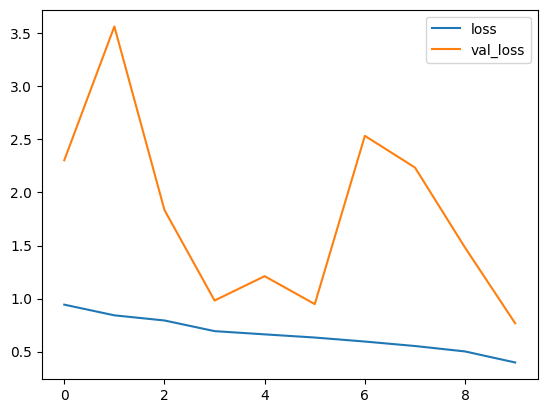

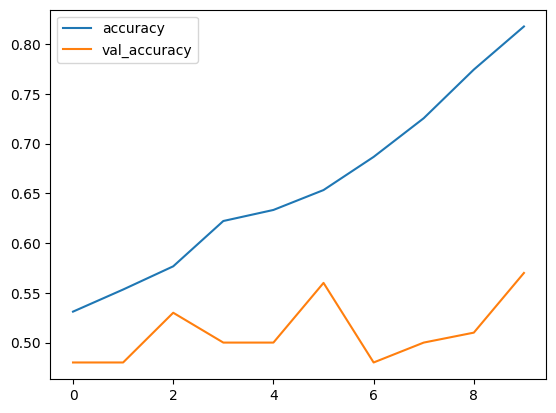

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

Class Names: ['cat', 'dog']

Testing CAT image:


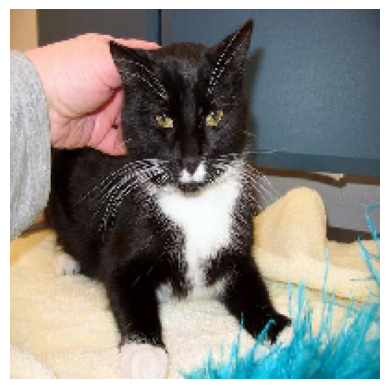

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Raw Prediction Value: 0.0066851866
Predicted Class: CAT
Confidence: 99.33%

Testing DOG image:


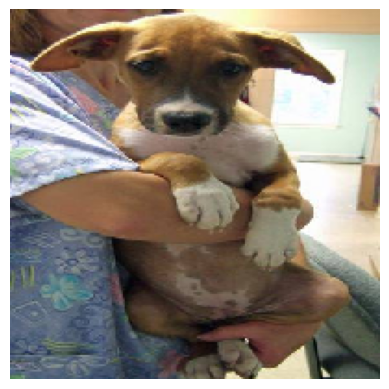

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Raw Prediction Value: 0.006552046
Predicted Class: CAT
Confidence: 99.34%


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# 🔹 CHECK CLASS LABELS (Run once after training)
# Use train_datagen which was defined, and its class_names attribute
print("Class Names:", train_datagen.class_names)

# 🔹 Reverse dictionary (index → label)
# Create a dictionary mapping index (0, 1) to class name ('cat', 'dog' or vice-versa)
class_labels = {i: name for i, name in enumerate(train_datagen.class_names)}


def predict_image(image_path):
    # Load image
    img = image.load_img(image_path, target_size=(200, 200))

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Convert to array
    img_array = image.img_to_array(img)

    # Normalize (IMPORTANT if you used rescale=1./255 in training)
    img_array = img_array / 255.0

    # Expand dimensions
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)

    probability = prediction[0][0]
    predicted_class_index = int(probability > 0.5)

    print("Raw Prediction Value:", probability)
    print("Predicted Class:", class_labels[predicted_class_index].upper())
    print("Confidence: {:.2f}%".format(
        probability*100 if predicted_class_index==1 else (1-probability)*100
    ))


# 🔹 Test with sample images
cat_subdir = '/content/train_transformed/cat'
dog_subdir = '/content/train_transformed/dog'

if os.path.exists(cat_subdir) and len(os.listdir(cat_subdir)) > 0:
    sample_cat_image = os.path.join(cat_subdir, os.listdir(cat_subdir)[0])
    print("\nTesting CAT image:")
    predict_image(sample_cat_image)

if os.path.exists(dog_subdir) and len(os.listdir(dog_subdir)) > 0:
    sample_dog_image = os.path.join(dog_subdir, os.listdir(dog_subdir)[0])
    print("\nTesting DOG image:")
    predict_image(sample_dog_image)